<p align="center" style="font-size:24px;"><b>HW1 - Vertebral Column Data</b></p>


### (a) Download Data

Package imports

In [357]:
from scipy.io import arff
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, precision_score, f1_score, DistanceMetric

Get the Vertebral Column Data Set

In [358]:
column_2c_data, column_2c_meta = arff.loadarff("../data/vertebral_column_data/column_2C_weka.arff")
column_2c_df = pd.DataFrame(column_2c_data)
# Replace Normal and Abnormal to 0 and 1 in "class" category
column_2c_df["class"] = column_2c_df["class"].map({b"Normal": 0, b"Abnormal": 1})
column_2c_df.head()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,1
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,1
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,1
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,1
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,1


### (b) Pre-Processing and Exploratory Data Analysis

#### i. Scatterplots

Make scatterplots of the independent variables in the dataset.

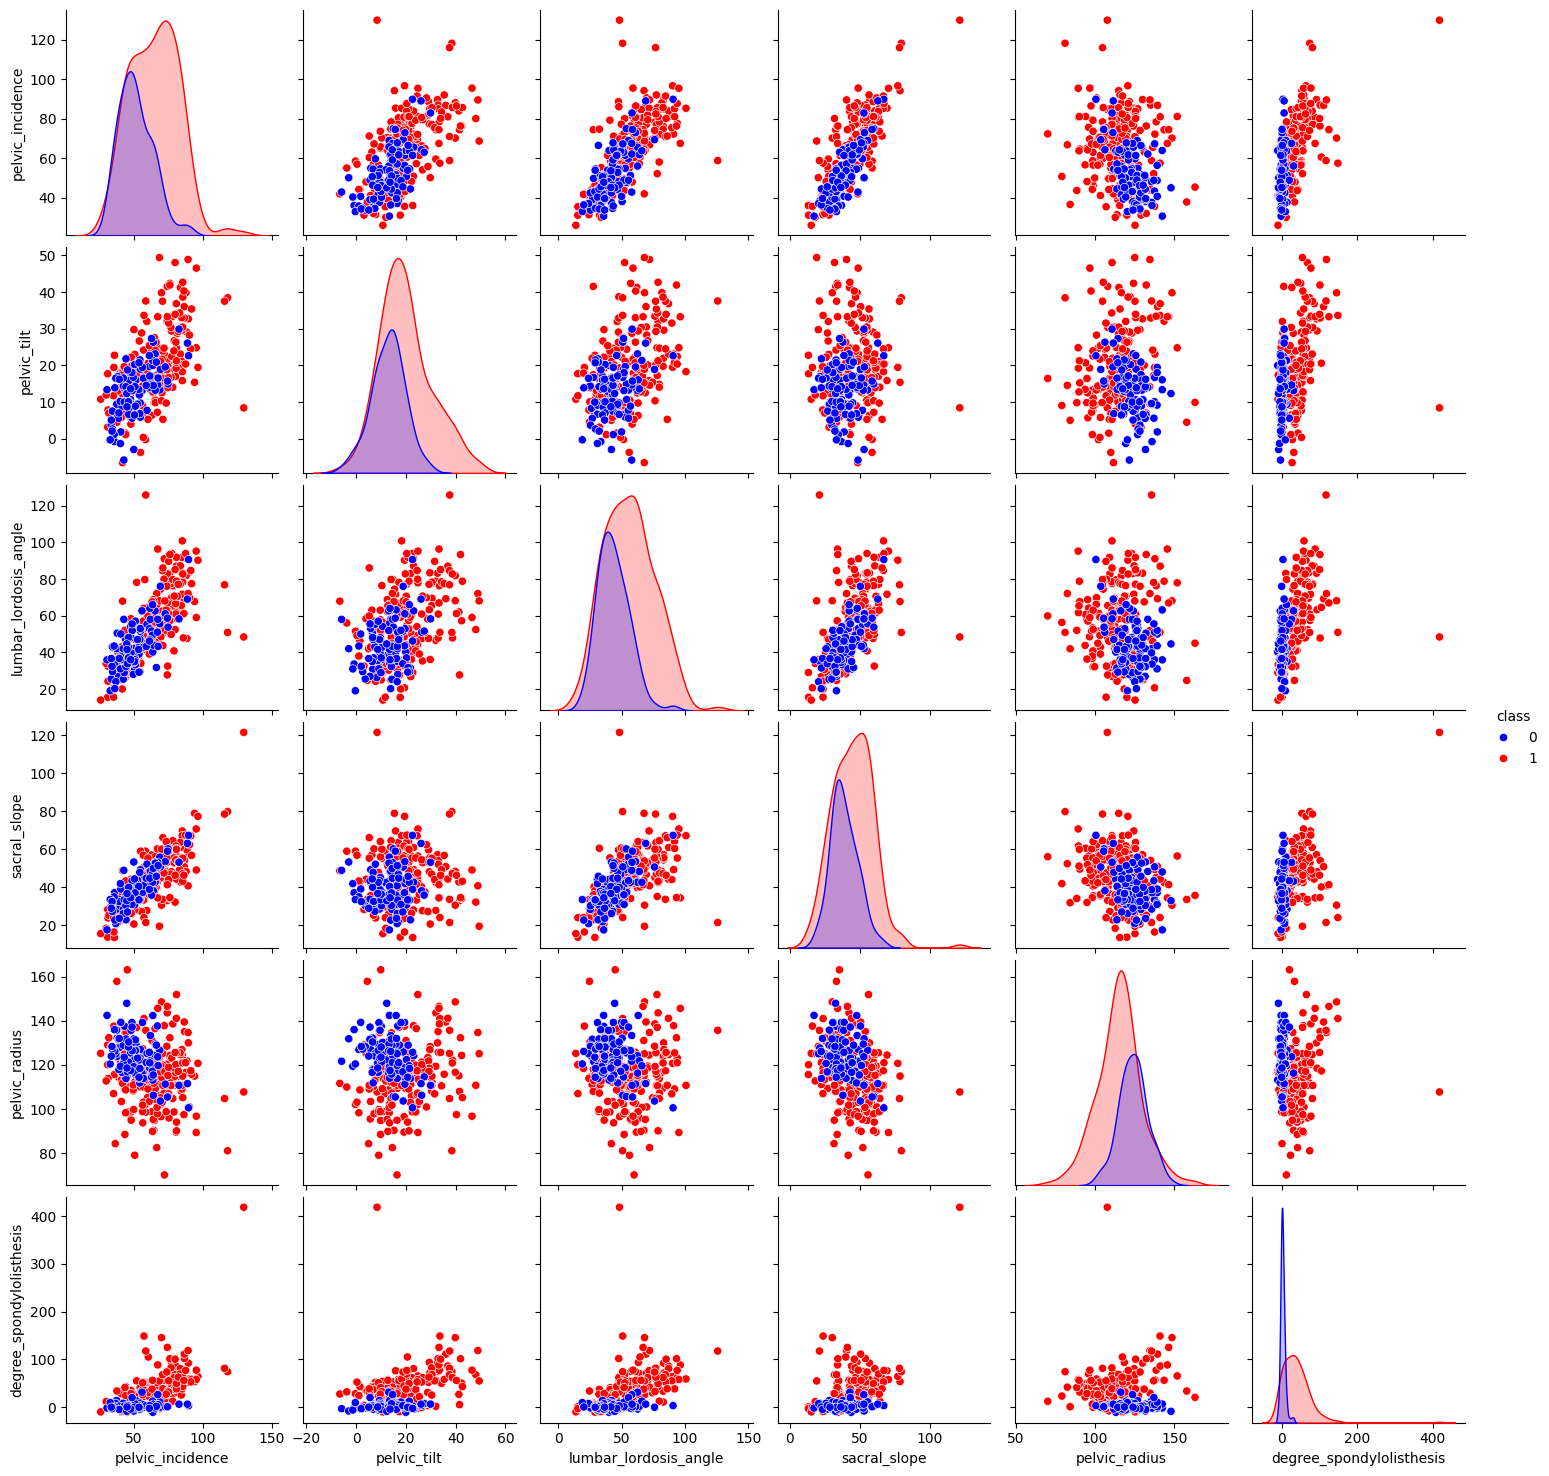

In [359]:
# Use all independent variables (i.e., all columns except "class") for the scatterplots
# Blue is normal(class 0), Red is abnormal(class 1)
sns.pairplot(
    column_2c_df,
    vars=column_2c_df.columns.drop("class"),
    hue="class",
    palette={0: "blue", 1: "red"}
)

plt.show()

#### ii. Boxplots

Make boxplots for each of the independent variables.

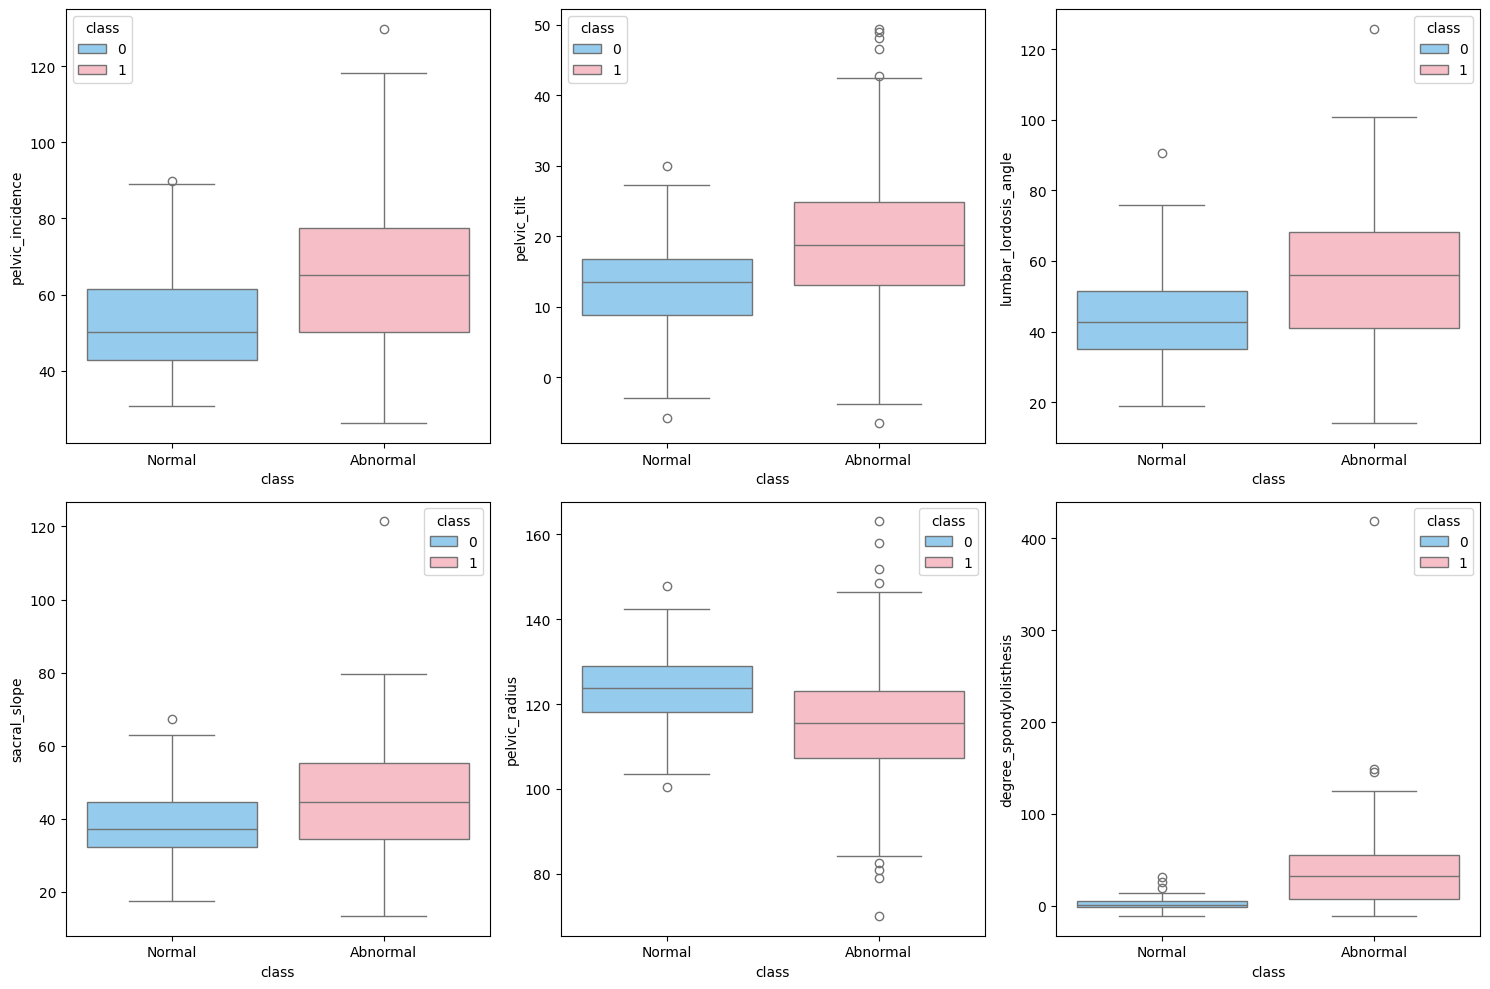

In [360]:
independent_vars = column_2c_df.columns.drop("class")

# Set up the number of rows and columns
ncols = 3
nrows = math.ceil(len(independent_vars) / ncols)

# Set up the figure size
plt.figure(figsize=(5*ncols, 5*nrows))

# Plot for each independent variable
for i in range(len(independent_vars)):
    plt.subplot(nrows, ncols, i+1)
    
    sns.boxplot(
        x="class",
        y=independent_vars[i],
        data=column_2c_df,
        hue="class",
        palette={0: "lightskyblue", 1: "lightpink"}
    )
    
    # Mark labels of each box
    plt.xticks([0, 1], ["Normal", "Abnormal"])

plt.tight_layout()
plt.show()

#### iii. Split Data Set

Select the first 70 rows of Class 0 and the first 140 rows of Class 1 as the
training set and the rest of the data as the test set.

In [361]:
# Separate data by class 
class0_df = column_2c_df[column_2c_df["class"] == 0]
class1_df = column_2c_df[column_2c_df["class"] == 1]

# Select the first 70 rows of Class 0 and the first 140 rows of Class 1 as the training set
train_df = pd.concat([class0_df.iloc[:70], class1_df.iloc[:140]], ignore_index=True)
print("The shape of train_df is {}.".format(train_df.shape))

# Select the rest of the data as the test set
test_df = pd.concat([class0_df.iloc[70:], class1_df.iloc[140:]], ignore_index=True)
print("The shape of test_df is {}.".format(test_df.shape))


The shape of train_df is (210, 7).
The shape of test_df is (100, 7).


### (c) Classification

#### i. Euclidean Metric

Generate a KNN model with Euclidean metric, using k=208 as example. And show the prediction result.

In [362]:
# Separate independent variables and label in train and test datasets
X_train = train_df.drop("class", axis=1)
y_train = train_df["class"]

X_test = test_df.drop("class", axis=1)
y_test = test_df["class"]

# Initialize the knn model with k=208 and use Euclidean metric
k = 208
knn_clf = KNeighborsClassifier(n_neighbors=k, metric="euclidean")

knn_clf.fit(X_train, y_train)

y_pred = knn_clf.predict(X_test)

print("With k={}, the model predicts labels as follow:\n".format(k), y_pred.tolist())
print("The truth of labels is:\n", y_test.to_list())

With k=208, the model predicts labels as follow:
 [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
The truth of labels is:
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


#### ii. Test Data

Test all the data in the test database with k nearest neighbors. k ∈ {208, 207, ..., 2, 1}.

In [363]:
# Use a dictionary to record all the knn model scores in the format 
# {k: (training_score, test_score)}
knn_scores = {}

for k in range(208, 0, -1):
    knn_clf = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    knn_clf.fit(X_train, y_train)

    training_score = knn_clf.score(X_train, y_train)
    test_score = knn_clf.score(X_test, y_test)

    knn_scores[k] = (training_score, test_score)
    

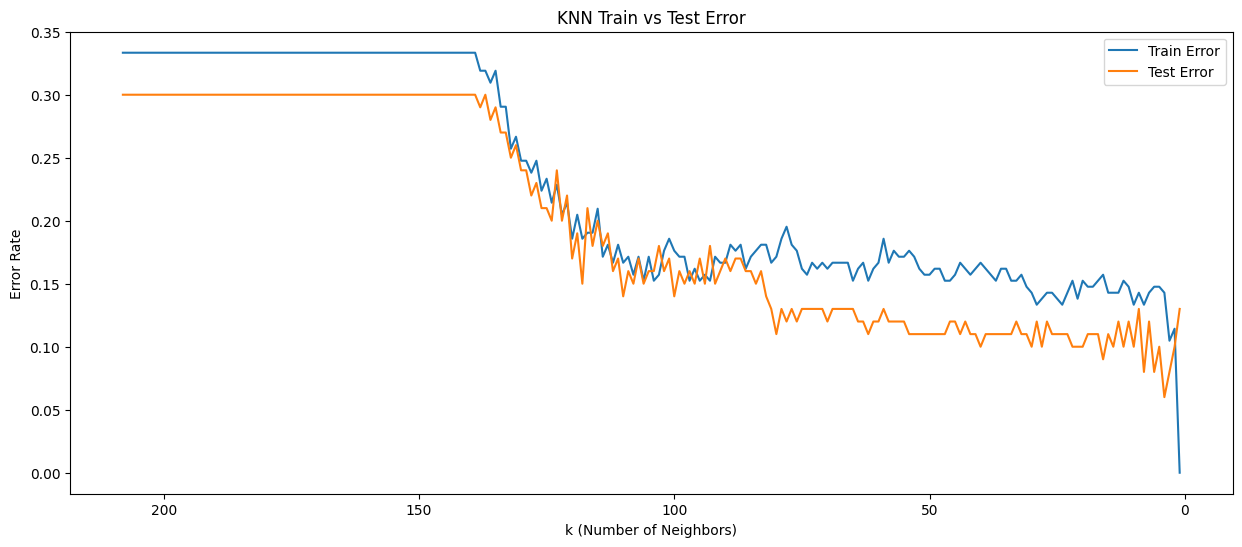

In [364]:
# Plot the scores of each knn model with different k's
k_values = sorted(knn_scores.keys(), reverse=True)
train_scores = [knn_scores[k][0] for k in k_values]
test_scores = [knn_scores[k][1] for k in k_values]

plt.figure(figsize=(15,6))
plt.plot(k_values, [1-ts for ts in train_scores], label="Train Error")
plt.plot(k_values, [1-ts for ts in test_scores], label="Test Error")
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Error Rate")
plt.title("KNN Train vs Test Error")
plt.legend()
plt.gca().invert_xaxis()        # In reverse order
plt.show()

We can see from the figure that both train error and test error drops generally when k is getting smaller. Now we zoom in the figure with a smaller range of k to be more precise.

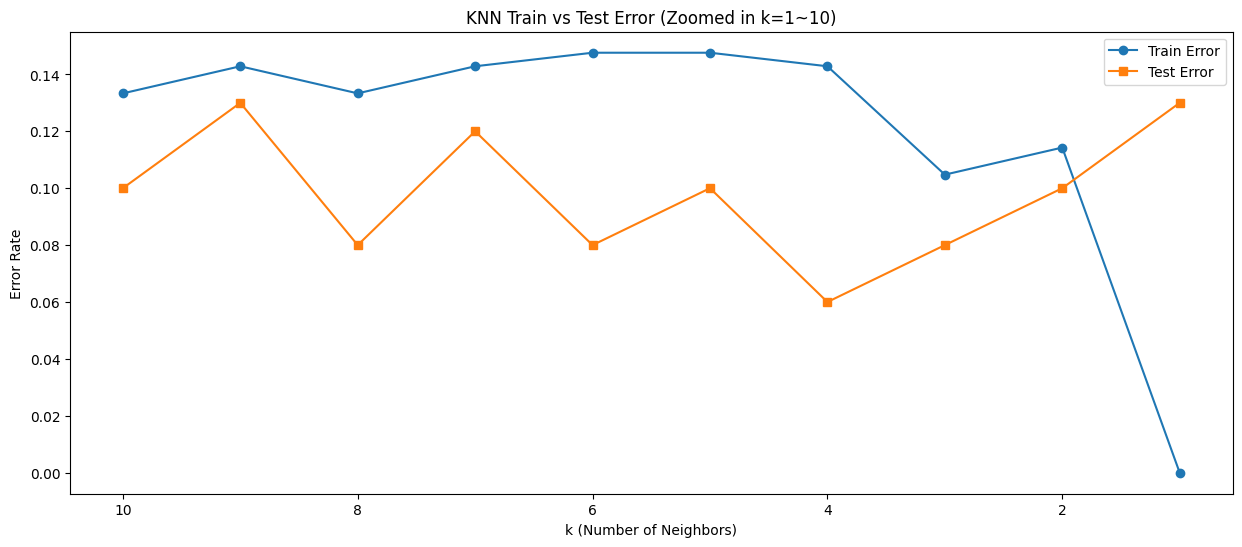

In [365]:
# Select k values between 1 and 10
zoom_k_values = [k for k in k_values if 1 <= k <= 10]
zoom_train_scores = [knn_scores[k][0] for k in zoom_k_values]
zoom_test_scores = [knn_scores[k][1] for k in zoom_k_values]

plt.figure(figsize=(15,6))
plt.plot(zoom_k_values, [1-ts for ts in zoom_train_scores], label="Train Error", marker='o')
plt.plot(zoom_k_values, [1-ts for ts in zoom_test_scores], label="Test Error", marker='s')
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Error Rate")
plt.title("KNN Train vs Test Error (Zoomed in k=1~10)")
plt.legend()
plt.gca().invert_xaxis()        # In reverse order
plt.show()

From the perspective of looking for lowest error rate, we can see that the model has lowest test error when k=4. Although when k=1, the model has 0 train error, the test error becomes higher. This means that the model is over-fitting.

Now we can conclude that the optimal k, i.e. **k<sup>*</sup>=4**.

When k=k<sup>*</sup>, we calculate the the confusion matrix, true positive rate, true negative rate, precision, and F<sub>1</sub>-score as below.

In [366]:
optimal_k = 4
best_knn_clf = KNeighborsClassifier(n_neighbors=optimal_k, metric="euclidean")

best_knn_clf.fit(X_train, y_train)

y_pred = best_knn_clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)       # [[TN, FP],[FN, TP]]
print("Confusion Matrix:\n", cm)

tn, fp, fn, tp = cm.ravel()

tpr = tp / (tp + fn)        # True Positive Rate
tnr = tn / (tn + fp)        # True Negative Rate

precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"True Positive Rate (TPR): {tpr:.4f}")
print(f"True Negative Rate (TNR): {tnr:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1-score: {f1:.4f}")

Confusion Matrix:
 [[25  5]
 [ 1 69]]
True Positive Rate (TPR): 0.9857
True Negative Rate (TNR): 0.8333
Precision: 0.9324
F1-score: 0.9583


#### iii. Learning Curve

Plot the best test error rate, which is obtained by some value of k, against the size of training set, when the size of training set is N ∈ {10, 20, 30, . . . , 210}.

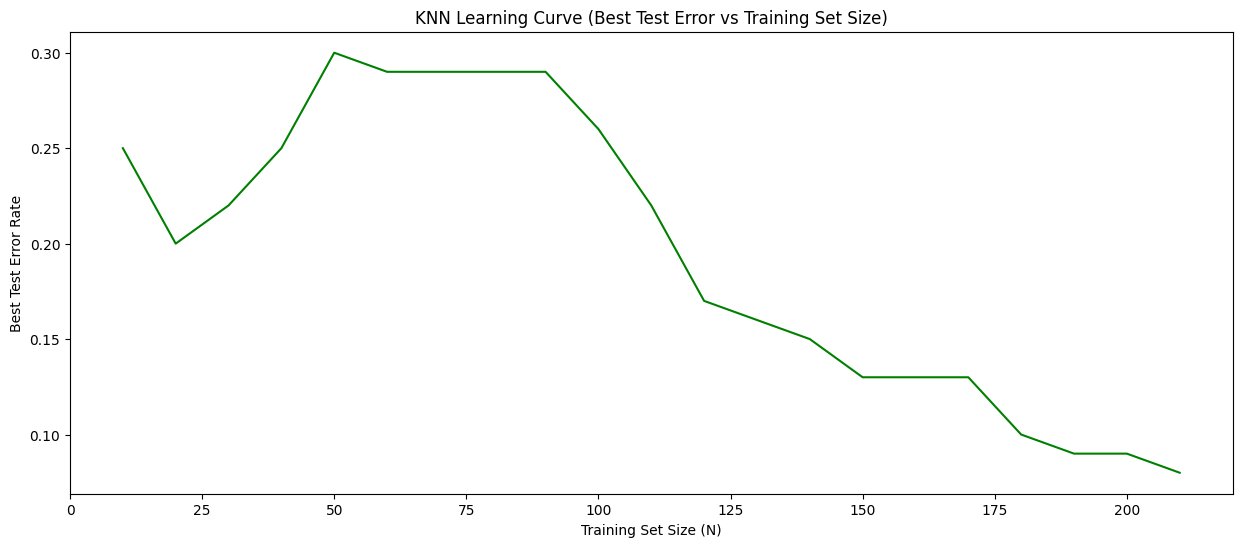

In [367]:
n_start = 10
n_end = 211
n_gap = 10
n_values = range(n_start, n_end, n_gap)
lowest_test_errors = []

for n in n_values:

    # Select the first n//3 rows of Class 0 
    # and the first n - n//3 rows of Class 1 as the training set
    sub_train_df = pd.concat([class0_df.iloc[:n//3], class1_df.iloc[:n - n//3]], ignore_index=True)
    
    sub_X_train = sub_train_df.drop("class", axis=1)
    sub_y_train = sub_train_df["class"]

    k_gap = 5
    k_values = range(1, n, k_gap)
    knn_lowest_error = 1

    for k in k_values:
        knn_clf = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
        knn_clf.fit(sub_X_train, sub_y_train)

        test_score = knn_clf.score(X_test, y_test)

        knn_lowest_error = min(1 - test_score, knn_lowest_error)
        
    lowest_test_errors.append(knn_lowest_error)

plt.figure(figsize=(15,6))
plt.plot(n_values, lowest_test_errors, color='green')
plt.title("KNN Learning Curve (Best Test Error vs Training Set Size)")
plt.xlabel("Training Set Size (N)")
plt.ylabel("Best Test Error Rate")
plt.show()

### (d) Other Metrics

#### i. Minkowski Distance.

##### A. Manhattan Distance with p = 1.

Look for optimal k for KNN model of Manhattan distance with p=1.

In [368]:
k_gap = 5
k_values = range(1, 200, k_gap)

man_knn_scores = {}

for k in k_values:
    knn_clf = KNeighborsClassifier(n_neighbors=k, metric="minkowski", p=1)
    knn_clf.fit(X_train, y_train)

    training_score = knn_clf.score(X_train, y_train)
    test_score = knn_clf.score(X_test, y_test)

    man_knn_scores[k] = (training_score, test_score)

max_test_score = max(score[1] for score in man_knn_scores.values())
best_ks = [k for k, score in man_knn_scores.items() if score[1] == max_test_score]

print("The optimal k values are:\n")
for k in best_ks:
    train_error = 1 - man_knn_scores[k][0]
    test_error = 1 - man_knn_scores[k][1]
    print(f"k={k}: (train_error={train_error:.4f}, test_error={test_error:.4f})")

The optimal k values are:

k=1: (train_error=0.0000, test_error=0.1100)
k=6: (train_error=0.1381, test_error=0.1100)
k=11: (train_error=0.1429, test_error=0.1100)
k=26: (train_error=0.1667, test_error=0.1100)


Plot the test error rate against different k's.

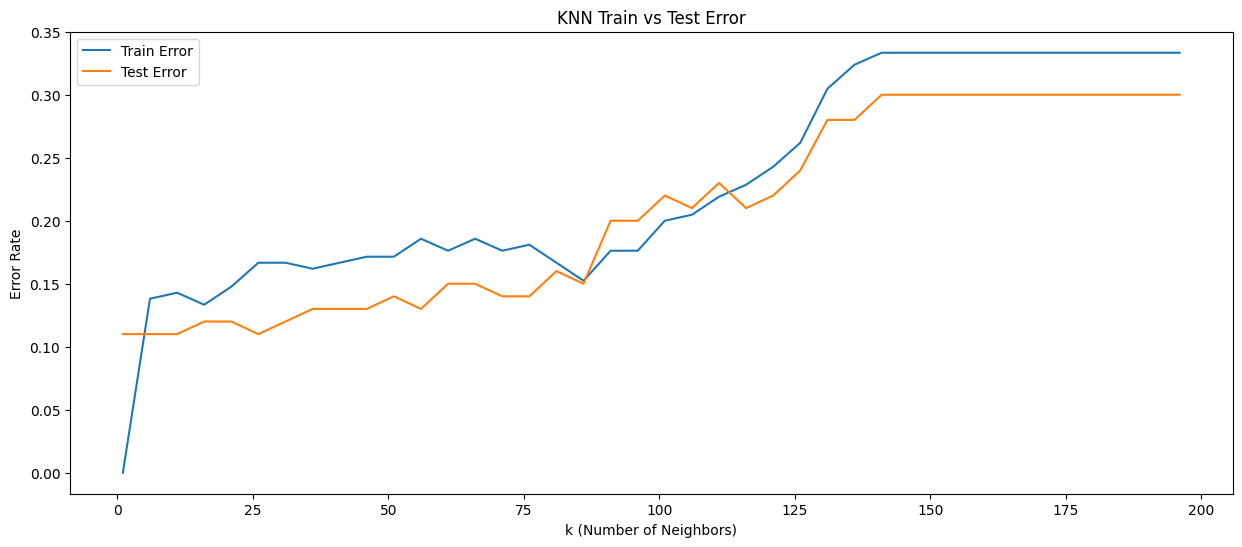

In [369]:
# Plot the error rates of each knn model with different k's
man_k_values = sorted(man_knn_scores.keys())
man_train_scores = [man_knn_scores[k][0] for k in k_values]
man_test_scores = [man_knn_scores[k][1] for k in k_values]

plt.figure(figsize=(15,6))
plt.plot(k_values, [1-ts for ts in man_train_scores], label="Train Error") # 1-ts = error rate
plt.plot(k_values, [1-ts for ts in man_test_scores], label="Test Error")
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Error Rate")
plt.title("KNN Train vs Test Error")
plt.legend()
plt.show()

Zoom in for the k values below 75 for details.

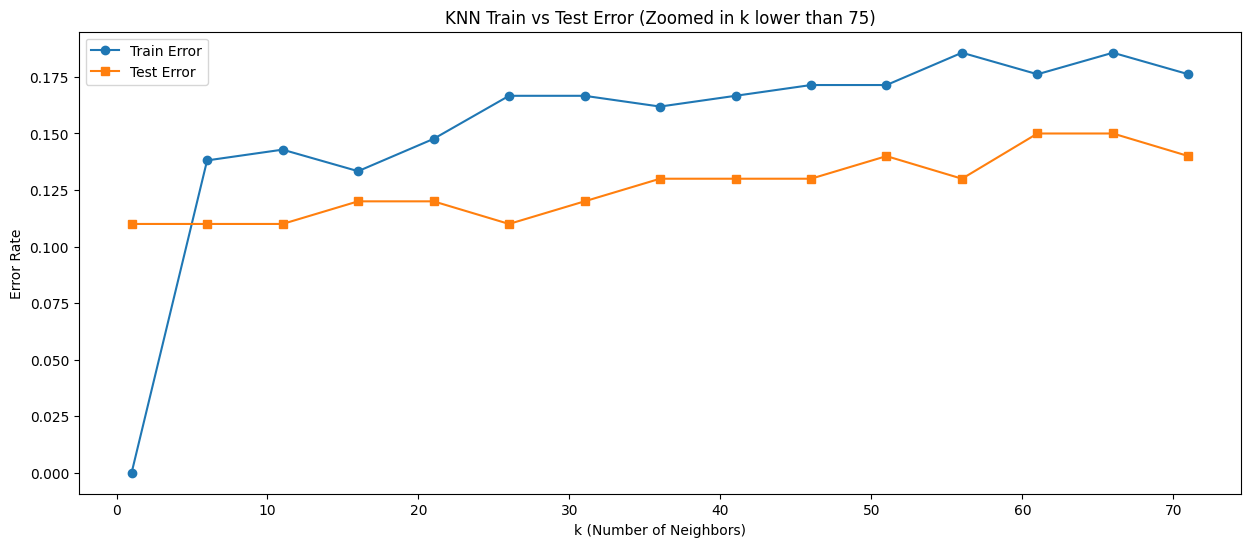

In [370]:
zoom_k_values = range(1, 75, k_gap)
zoom_train_scores = [man_knn_scores[k][0] for k in zoom_k_values]
zoom_test_scores = [man_knn_scores[k][1] for k in zoom_k_values]

plt.figure(figsize=(15,6))
plt.plot(zoom_k_values, [1-ts for ts in zoom_train_scores], label="Train Error", marker='o')
plt.plot(zoom_k_values, [1-ts for ts in zoom_test_scores], label="Test Error", marker='s')
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Error Rate")
plt.title("KNN Train vs Test Error (Zoomed in k lower than 75)")
plt.legend()
plt.show()

Now we can conclude that for the KNN model using Minkowski metric with p=1, the optimal k, i.e. **k<sup>*</sup>=1, 6, 11, 26**, with **test error 0.11**.

In [371]:
table_data = []

for k in best_ks:
    test_error = 1 - man_knn_scores[k][1]
    table_data.append({
        "best_k": k,
        "test_error": round(test_error, 2)
    })

best_k_df = pd.DataFrame(table_data)

print(best_k_df)

   best_k  test_error
0       1        0.11
1       6        0.11
2      11        0.11
3      26        0.11


##### B. With log10(p) in {0.1, 0.2, 0.3, ... ,1}.

We have k<sup>*</sup>=1, 6, 11, 26, we will use them one by one to find corresponding best log<sub>10</sub>(p). And for each exp_knn model, we will record all the log<sub>10</sub>(p) value with lowest error rate as best log<sub>10</sub>(p)'s.

In [372]:
log_10_p_values = np.arange(0.1, 1.1, 0.1)
p_values = 10 ** log_10_p_values

results = []

for man_best_k in best_ks:
    p_scores = []

    for p_value in p_values:
        exp_knn = KNeighborsClassifier(n_neighbors=man_best_k, metric="minkowski", p=p_value)
        exp_knn.fit(X_train, y_train)

        p_score = exp_knn.score(X_test, y_test)
        p_scores.append(p_score)

    highest_p_score = max(p_scores)

    best_log_10_ps = [
        np.round(np.log10(p_values[i]), 2) 
        for i in range(len(p_scores)) 
        if np.isclose(p_scores[i], highest_p_score)
    ]

    test_error = 1 - highest_p_score

    results.append({
        "best_k": man_best_k,
        "best_log_10_ps": ", ".join(map(str, best_log_10_ps)),
        "test_error": test_error
    })

results_df = pd.DataFrame(results)
print(results_df)

   best_k           best_log_10_ps  test_error
0       1       0.7, 0.8, 0.9, 1.0        0.11
1       6                      0.6        0.06
2      11  0.1, 0.2, 0.8, 0.9, 1.0        0.11
3      26       0.1, 0.2, 0.4, 0.6        0.10


In our experiments, for the Manhattan distance (Minkowski distance with p=1), we obtained a list of k-values that leads to the lowest error rate. And in the further search of optimal p-values, we also noticed that one optimal k can have multiple optimal log<sub>10</sub>(p) values to achieve the lowest error rate. This reflects that in our model, when p flucuates slightly, the predictive performance of the model remains stable.

Now based on our goal of minimizing the test_error, we can see that when k<sup>*</sup>=6, log<sub>10</sub>(p)<sup>*</sup>=0.6, we have the lowest error rate 0.06. And for all the other combinations, the error rates are between 0.10 and 0.11.

So we can conclude that **the optimal k is 6** and **the optimal log<sub>10</sub>(p) is 0.6**.

##### C. Chebyshev Distance With p -> infinity.

Look for optimal k of KNN model with Chebyshev Distance with p → ∞.

In [373]:
k_gap = 5
k_values = range(1, 200, k_gap)

cheb_knn_scores = {}

for k in k_values:
    knn_clf = KNeighborsClassifier(n_neighbors=k, metric="minkowski", p=np.inf)
    knn_clf.fit(X_train, y_train)

    training_score = knn_clf.score(X_train, y_train)
    test_score = knn_clf.score(X_test, y_test)

    cheb_knn_scores[k] = (training_score, test_score)

max_test_score = max(score[1] for score in cheb_knn_scores.values())
cheb_best_ks = [k for k, score in cheb_knn_scores.items() if score[1] == max_test_score]

# Print all the best ks in a table
table_data = []
for k in cheb_best_ks:
    test_error = round(1 - cheb_knn_scores[k][1], 4)
    table_data.append({"best_k": k, "test_error": test_error})

cheb_results_df = pd.DataFrame(table_data)
print(cheb_results_df)

   best_k  test_error
0      16        0.08


#### ii. Mahalanobis Distance.

Look for optimal k of KNN model with Mahalanobis distance.

In [374]:
cov_matrix = np.cov(X_train.T)      # covariance matrix
inv_matrix = np.linalg.pinv(cov_matrix)     # pseudo-inverse

k_gap = 5
k_values = range(1, 200, k_gap)

mahal_knn_scores = {}

for k_value in k_values:
    knn = KNeighborsClassifier(n_neighbors=k_value, metric="mahalanobis", metric_params={"VI": inv_matrix})
    
    knn.fit(X_train, y_train)
    
    train_score = knn.score(X_train, y_train)
    test_score = knn.score(X_test, y_test)
    
    mahal_knn_scores[k_value] = (train_score, test_score)

max_test_score = max(score[1] for score in mahal_knn_scores.values())

mahal_best_ks = [k_value for k_value, score in mahal_knn_scores.items() if score[1] == max_test_score]

table_data = []
for best_k in mahal_best_ks:
    table_data.append({
        "best_k": best_k,
        "test_error": round(1 - mahal_knn_scores[best_k][1], 2)
    })

mahal_results_df = pd.DataFrame(table_data)
print(mahal_results_df)

   best_k  test_error
0       1        0.15


Now we summarize all the optimal k's and p values with different metrics in a table.

In [375]:
summary_data = [
    {
        "Metric": "Manhattan",
        "k*": "1, 6, 11, 26",
        "p*": "1",
        "test_error": "0.11"
    },
    {
        "Metric": "Minkowski with log10 p",
        "k*": "6",
        "p*": "0.6",
        "test_error": "0.06"
    },
    {
        "Metric": "Chebyshev with p -> infinity",
        "k*": "16",
        "p*": "inf",
        "test_error": "0.08"
    },
    {
        "Metric": "Mahalanobis",
        "k*": "1",
        "p*": "inv. cov matrix",
        "test_error": "0.15"
    }
]

summary_df = pd.DataFrame(summary_data)

print(summary_df)

                         Metric            k*               p* test_error
0                     Manhattan  1, 6, 11, 26                1       0.11
1        Minkowski with log10 p             6              0.6       0.06
2  Chebyshev with p -> infinity            16              inf       0.08
3                   Mahalanobis             1  inv. cov matrix       0.15


### (e) Weighted Decision

Apply weighted voting in KNN, where each neighbor’s vote is weighted by the inverse of its distance to the query point.

In [376]:
k_gap = 5
k_values = range(1, 200, k_gap)

metrics = ["euclidean", "manhattan", "chebyshev"]

results = []

for metric in metrics:
    scores = {}
    for k in k_values:
        knn = KNeighborsClassifier(
            n_neighbors=k,
            metric=metric,
            weights="distance"  # weighted voting
        )
        knn.fit(X_train, y_train)

        test_score = knn.score(X_test, y_test)
        scores[k] = test_score

    # Find best k for current metric
    max_score = max(scores.values())
    best_ks = [k for k, s in scores.items() if s == max_score]
    best_error = 1 - max_score

    results.append({
        "Metric": metric,
        "k*": ", ".join(map(str, best_ks)),
        "test_error": round(best_error, 2)
    })

results_df = pd.DataFrame(results)
print(results_df)


      Metric                  k*  test_error
0  euclidean                   6        0.10
1  manhattan                  26        0.10
2  chebyshev  16, 31, 36, 41, 61        0.11


### (f) Training Error Rate

The lowest training error rate I achieved in this homework is **0.0**, when **k=1**.

### References:

1. https://www.geeksforgeeks.org/machine-learning/ml-implementation-of-knn-classifier-using-sklearn/
2. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
3. https://www.geeksforgeeks.org/machine-learning/k-nearest-neighbours/
4. https://medium.com/@slavadubrov/understanding-machine-learning-robustness-why-it-matters-and-how-it-affects-your-models-5e2cb5838dab
5. https://medium.com/@adityachandavale/knn-distance-metrics-and-how-they-work-mathematically-d58f65f0bd06
6. https://www.kaggle.com/discussions/questions-and-answers/428879
